<div class="alert alert-info alert-warning" style="background-color: white; color: black; text-align: center;">
    <h1><span style="color: red;">Ozan MÖHÜRCÜ</span></h1>
    <h1><span style="color: red;">Data Analyst | Data Scientist</span></h1>
    <div style="text-align: center; font-family: Arial, sans-serif; margin-top: 20px;">
        <a href="https://www.linkedin.com/in/ozanmhrc/" style="text-decoration: none; color: #fff; margin: 0 10px;">
            <span style="background-color: #0077B5; padding: 8px 20px; border-radius: 5px; font-size: 14px; display: inline-block; width: 120px; text-align: center;">LinkedIn</span>
        </a>
        <a href="https://github.com/Ozan-Mohurcu" style="text-decoration: none; color: #fff; margin: 0 10px;">
            <span style="background-color: #333; padding: 8px 20px; border-radius: 5px; font-size: 14px; display: inline-block; width: 120px; text-align: center;">GitHub</span>
        </a>
        <a href="https://ozan-mohurcu.github.io/" style="text-decoration: none; color: #fff; margin: 0 10px;">
            <span style="background-color: #6A1B9A; padding: 8px 20px; border-radius: 5px; font-size: 14px; display: inline-block; width: 120px; text-align: center;">Portfolio</span>
        </a>
    </div>
</div>

<h2 style="
    background-color:#1a1a1a; 
    color:#FFD700; 
    padding:10px; 
    border-radius:6px; 
    font-family:sans-serif; 
    text-shadow: 0 0 5px #FFD700, 0 0 10px #FFD700, 0 0 20px #FFA500, 0 0 30px #FFA500, 0 0 40px #FFD700;
    ">
📥 Data Loading
</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv("/kaggle/input/playground-series-s5e9/train.csv", index_col="id")
test = pd.read_csv("/kaggle/input/playground-series-s5e9/test.csv", index_col="id")

In [2]:
train.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
id,,,,,,,,,,
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524164 entries, 0 to 524163
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   RhythmScore                524164 non-null  float64
 1   AudioLoudness              524164 non-null  float64
 2   VocalContent               524164 non-null  float64
 3   AcousticQuality            524164 non-null  float64
 4   InstrumentalScore          524164 non-null  float64
 5   LivePerformanceLikelihood  524164 non-null  float64
 6   MoodScore                  524164 non-null  float64
 7   TrackDurationMs            524164 non-null  float64
 8   Energy                     524164 non-null  float64
 9   BeatsPerMinute             524164 non-null  float64
dtypes: float64(10)
memory usage: 44.0 MB


<h2 style="
    background-color:#1a1a1a; 
    color:#FFD700; 
    padding:10px; 
    border-radius:6px; 
    font-family:sans-serif; 
    text-shadow: 0 0 5px #FFD700, 0 0 10px #FFD700, 0 0 20px #FFA500, 0 0 30px #FFA500, 0 0 40px #FFD700;
    ">
📊 Data Visualization
</h2>

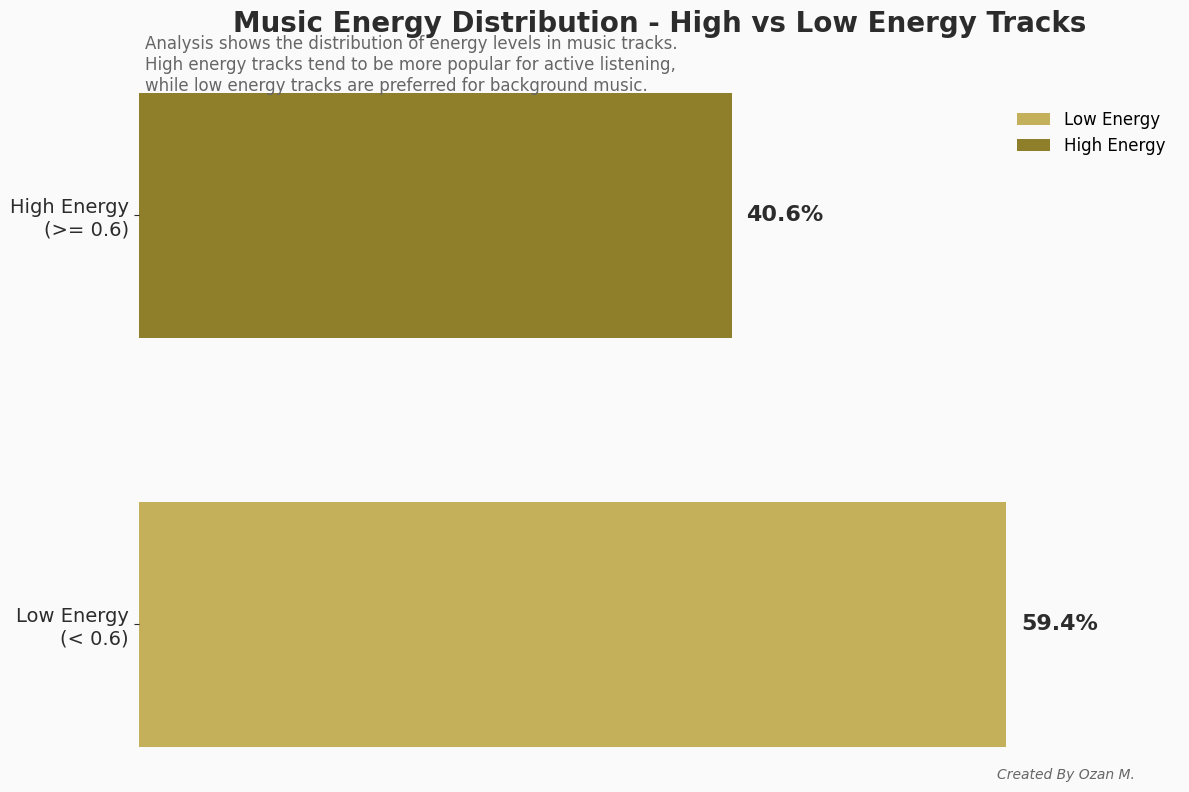

In [4]:
df = train.copy()

colors = ['#f8f4d9', '#c4b05a', '#8f7f2a', '#6b5500']

high_energy = (df['Energy'] >= 0.6).sum()
low_energy = (df['Energy'] < 0.6).sum()

categories = ['Low Energy\n(< 0.6)', 'High Energy\n(>= 0.6)']
values = [low_energy, high_energy]
percentages = [val/len(df)*100 for val in values]

fig, ax = plt.subplots(figsize=(12, 8))


bars = ax.barh(categories, percentages, color=[colors[1], colors[2]], height=0.6)


ax.set_title('Music Energy Distribution - High vs Low Energy Tracks', 
             fontsize=20, fontweight='bold', pad=20, color='#2c2c2c')


fig.text(0.125, 0.88, 'Analysis shows the distribution of energy levels in music tracks.\nHigh energy tracks tend to be more popular for active listening,\nwhile low energy tracks are preferred for background music.', 
         fontsize=12, color='#666666', ha='left')


legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor=colors[1], label='Low Energy'),
    plt.Rectangle((0,0),1,1, facecolor=colors[2], label='High Energy')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, 
          bbox_to_anchor=(1.0, 0.95), frameon=False)


for i, (bar, percentage) in enumerate(zip(bars, percentages)):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
            f'{percentage:.1f}%', ha='left', va='center', 
            fontsize=16, fontweight='bold', color='#2c2c2c')

ax.set_xlim(0, max(percentages) * 1.2)
ax.set_xlabel('')
ax.set_ylabel('')

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xticks([])

ax.tick_params(axis='y', labelsize=14, colors='#2c2c2c')

fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

fig.text(0.95, 0.02, 'Created By Ozan M.', 
         fontsize=10, color='#666666', ha='right', style='italic')

plt.tight_layout()
plt.show()

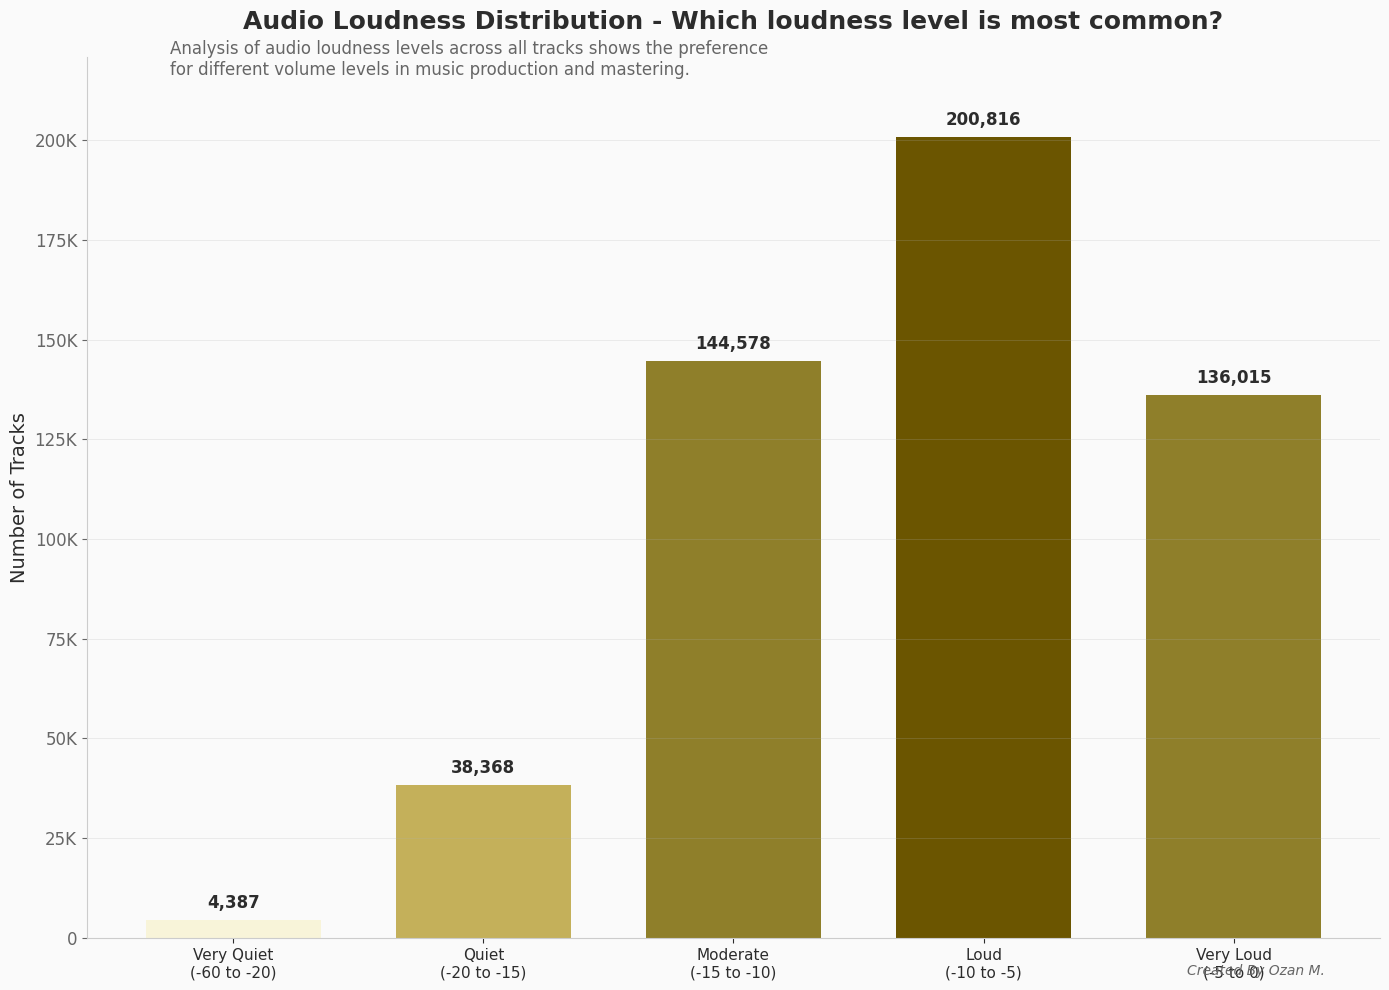

In [5]:
colors = ['#f8f4d9', '#c4b05a', '#8f7f2a', '#6b5500']

loudness_categories = []
loudness_counts = []

bins = [-60, -20, -15, -10, -5, 0]
labels = ['Very Quiet\n(-60 to -20)', 'Quiet\n(-20 to -15)', 'Moderate\n(-15 to -10)', 
          'Loud\n(-10 to -5)', 'Very Loud\n(-5 to 0)']

for i in range(len(bins)-1):
    count = ((df['AudioLoudness'] >= bins[i]) & (df['AudioLoudness'] < bins[i+1])).sum()
    loudness_categories.append(labels[i])
    loudness_counts.append(count)

fig, ax = plt.subplots(figsize=(14, 10))

bars = ax.bar(range(len(loudness_categories)), loudness_counts, 
              color=[colors[0], colors[1], colors[2], colors[3], colors[2]], 
              width=0.7)

ax.set_title('Audio Loudness Distribution - Which loudness level is most common?', 
             fontsize=18, fontweight='bold', pad=20, color='#2c2c2c')

fig.text(0.125, 0.92, 'Analysis of audio loudness levels across all tracks shows the preference\nfor different volume levels in music production and mastering.', 
         fontsize=12, color='#666666', ha='left')

ax.set_xticks(range(len(loudness_categories)))
ax.set_xticklabels(loudness_categories, fontsize=11, color='#2c2c2c')

for bar, count in zip(bars, loudness_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(loudness_counts)*0.01,
            f'{count:,}', ha='center', va='bottom', 
            fontsize=12, fontweight='bold', color='#2c2c2c')

ax.set_ylabel('Number of Tracks', fontsize=14, color='#2c2c2c')
ax.set_ylim(0, max(loudness_counts) * 1.1)

ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K' if x >= 1000 else str(int(x))))
ax.tick_params(axis='y', labelsize=12, colors='#666666')
ax.tick_params(axis='x', labelsize=11, colors='#2c2c2c')

fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

fig.text(0.95, 0.02, 'Created By Ozan M.', 
         fontsize=10, color='#666666', ha='right', style='italic')

plt.tight_layout()
plt.show()

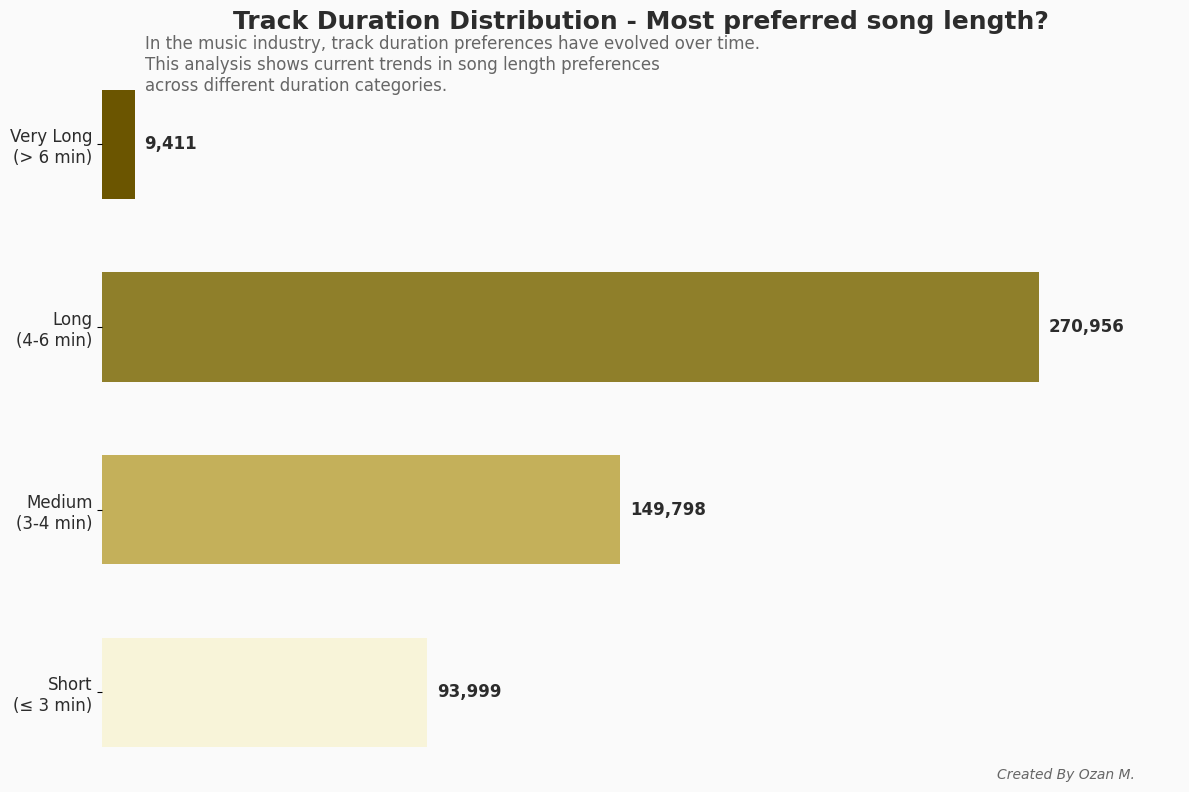

In [6]:
colors = ['#f8f4d9', '#c4b05a', '#8f7f2a', '#6b5500']

duration_minutes = df['TrackDurationMs'] / 60000

short_tracks = (duration_minutes <= 3).sum()
medium_tracks = ((duration_minutes > 3) & (duration_minutes <= 4)).sum()
long_tracks = ((duration_minutes > 4) & (duration_minutes <= 6)).sum()
very_long_tracks = (duration_minutes > 6).sum()

categories = ['Short\n(≤ 3 min)', 'Medium\n(3-4 min)', 'Long\n(4-6 min)', 'Very Long\n(> 6 min)']
values = [short_tracks, medium_tracks, long_tracks, very_long_tracks]

fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(categories))
bars = ax.barh(y_pos, values, color=colors, height=0.6)

ax.set_title('Track Duration Distribution - Most preferred song length?', 
             fontsize=18, fontweight='bold', pad=20, color='#2c2c2c')

fig.text(0.125, 0.88, 'In the music industry, track duration preferences have evolved over time.\nThis analysis shows current trends in song length preferences\nacross different duration categories.', 
         fontsize=12, color='#666666', ha='left')

ax.set_yticks(y_pos)
ax.set_yticklabels(categories, fontsize=12, color='#2c2c2c')

for i, (bar, value) in enumerate(zip(bars, values)):
    width = bar.get_width()
    ax.text(width + max(values)*0.01, bar.get_y() + bar.get_height()/2, 
            f'{value:,}', ha='left', va='center', 
            fontsize=12, fontweight='bold', color='#2c2c2c')

ax.set_xlim(0, max(values) * 1.15)
ax.set_xlabel('')
ax.set_ylabel('')

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xticks([])

fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

fig.text(0.95, 0.02, 'Created By Ozan M.', 
         fontsize=10, color='#666666', ha='right', style='italic')

plt.tight_layout()
plt.show()

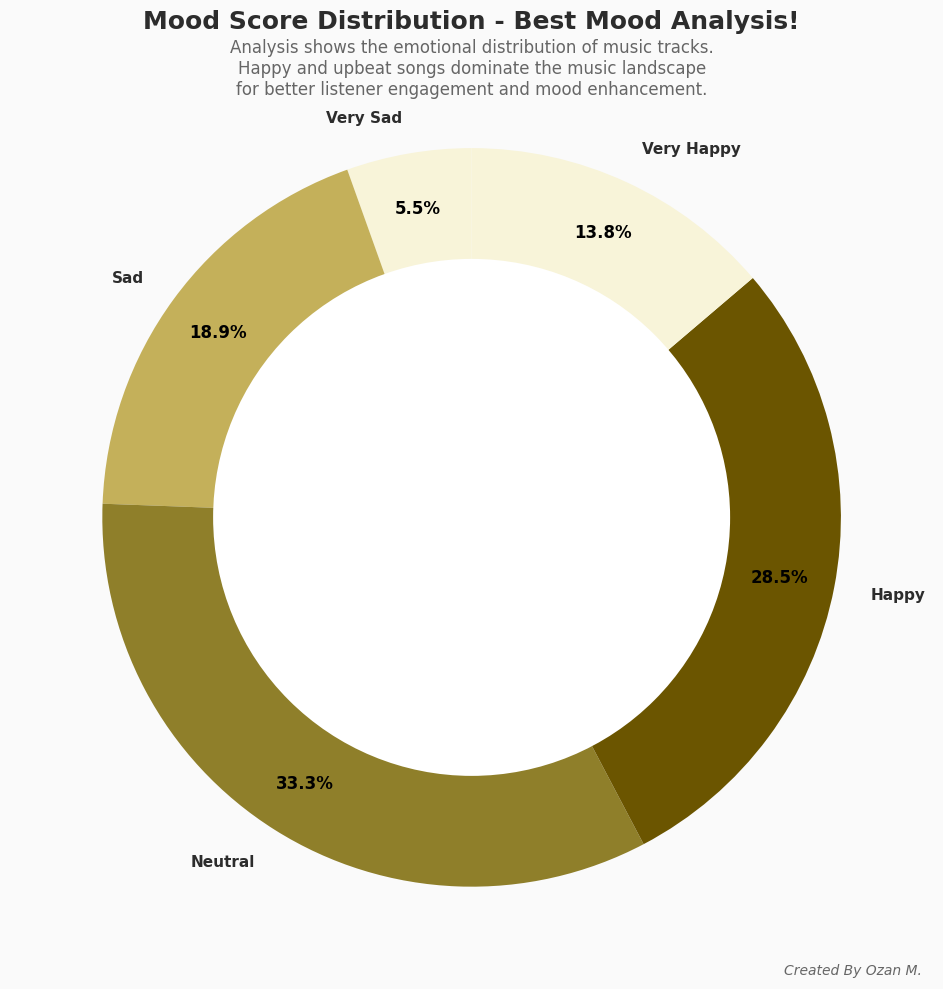

In [7]:
colors = ['#f8f4d9', '#c4b05a', '#8f7f2a', '#6b5500']

mood_ranges = [
    (0.0, 0.2, 'Very Sad'),
    (0.2, 0.4, 'Sad'),
    (0.4, 0.6, 'Neutral'),
    (0.6, 0.8, 'Happy'),
    (0.8, 1.0, 'Very Happy')
]

mood_counts = []
mood_labels = []

for min_val, max_val, label in mood_ranges:
    count = ((df['MoodScore'] >= min_val) & (df['MoodScore'] < max_val)).sum()
    mood_counts.append(count)
    mood_labels.append(label)

mood_counts[-1] += (df['MoodScore'] == 1.0).sum()

fig, ax = plt.subplots(figsize=(10, 10))

wedges, texts, autotexts = ax.pie(mood_counts, labels=mood_labels, colors=colors[:len(mood_counts)],
                                  autopct='%1.1f%%', startangle=90, pctdistance=0.85)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Mood Score Distribution - Best Mood Analysis!', 
             fontsize=18, fontweight='bold', pad=20, color='#2c2c2c')

fig.text(0.5, 0.90, 'Analysis shows the emotional distribution of music tracks.\nHappy and upbeat songs dominate the music landscape\nfor better listener engagement and mood enhancement.', 
         fontsize=12, color='#666666', ha='center')

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

for text in texts:
    text.set_fontsize(11)
    text.set_color('#2c2c2c')
    text.set_fontweight('bold')

fig.patch.set_facecolor('#fafafa')

fig.text(0.95, 0.02, 'Created By Ozan M.', 
         fontsize=10, color='#666666', ha='right', style='italic')

plt.tight_layout()
plt.show()

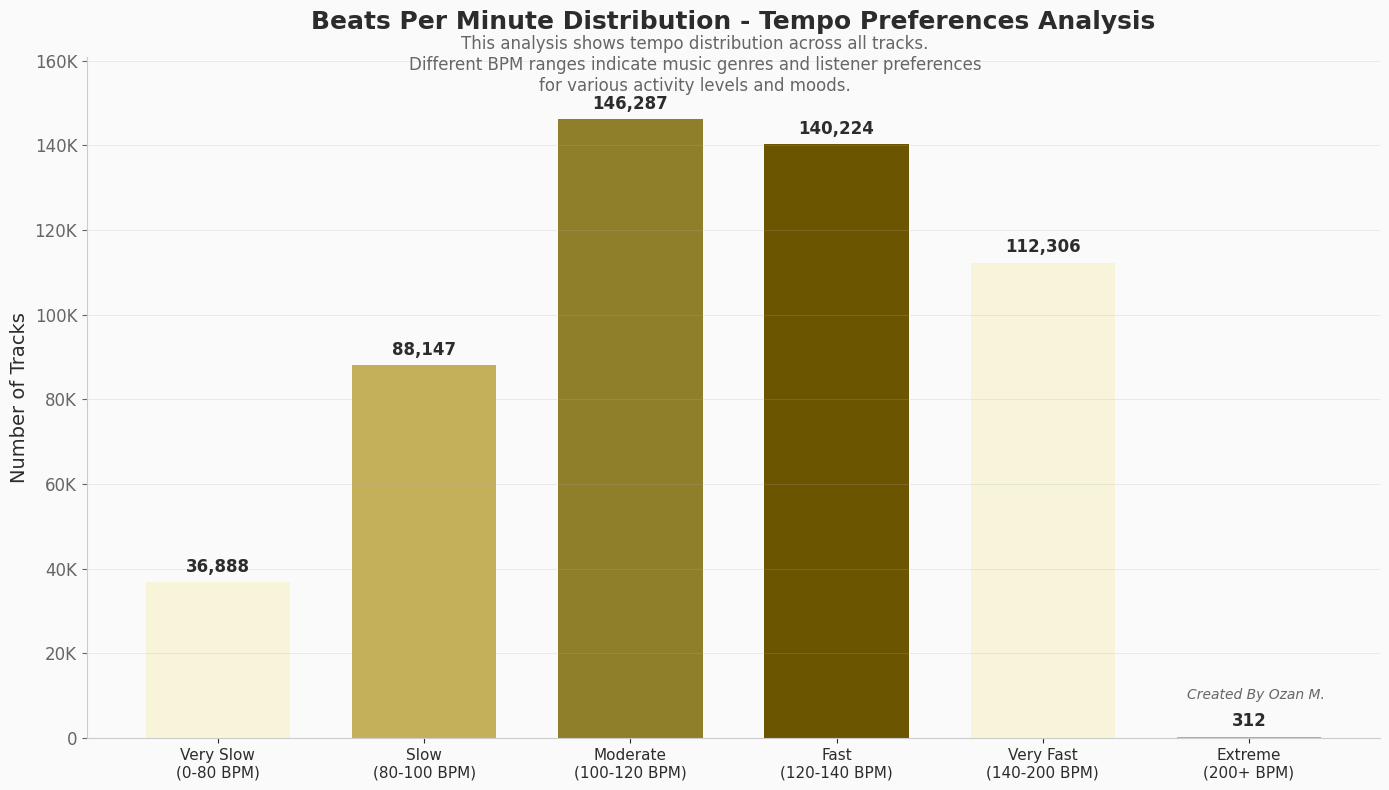

In [8]:
colors = ['#f8f4d9', '#c4b05a', '#8f7f2a', '#6b5500']

bpm_ranges = [
    (0, 80, 'Very Slow\n(0-80 BPM)'),
    (80, 100, 'Slow\n(80-100 BPM)'),
    (100, 120, 'Moderate\n(100-120 BPM)'),
    (120, 140, 'Fast\n(120-140 BPM)'),
    (140, 200, 'Very Fast\n(140-200 BPM)'),
    (200, 999, 'Extreme\n(200+ BPM)')
]

bpm_counts = []
bpm_labels = []

for min_bpm, max_bpm, label in bpm_ranges:
    count = ((df['BeatsPerMinute'] >= min_bpm) & (df['BeatsPerMinute'] < max_bpm)).sum()
    if count > 0:
        bpm_counts.append(count)
        bpm_labels.append(label)

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.bar(range(len(bpm_labels)), bpm_counts, color=colors[:len(bpm_counts)], width=0.7)

ax.set_title('Beats Per Minute Distribution - Tempo Preferences Analysis', 
             fontsize=18, fontweight='bold', pad=20, color='#2c2c2c')

fig.text(0.5, 0.88, 'This analysis shows tempo distribution across all tracks.\nDifferent BPM ranges indicate music genres and listener preferences\nfor various activity levels and moods.', 
         fontsize=12, color='#666666', ha='center')

ax.set_xticks(range(len(bpm_labels)))
ax.set_xticklabels(bpm_labels, fontsize=11, color='#2c2c2c')

for bar, count in zip(bars, bpm_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(bpm_counts)*0.01,
            f'{count:,}', ha='center', va='bottom', 
            fontsize=12, fontweight='bold', color='#2c2c2c')

ax.set_ylabel('Number of Tracks', fontsize=14, color='#2c2c2c')
ax.set_ylim(0, max(bpm_counts) * 1.1)

ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K' if x >= 1000 else str(int(x))))
ax.tick_params(axis='y', labelsize=12, colors='#666666')
ax.tick_params(axis='x', labelsize=11, colors='#2c2c2c')

fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

fig.text(0.95, 0.12, 'Created By Ozan M.', 
         fontsize=10, color='#666666', ha='right', style='italic')

plt.tight_layout()
plt.show()

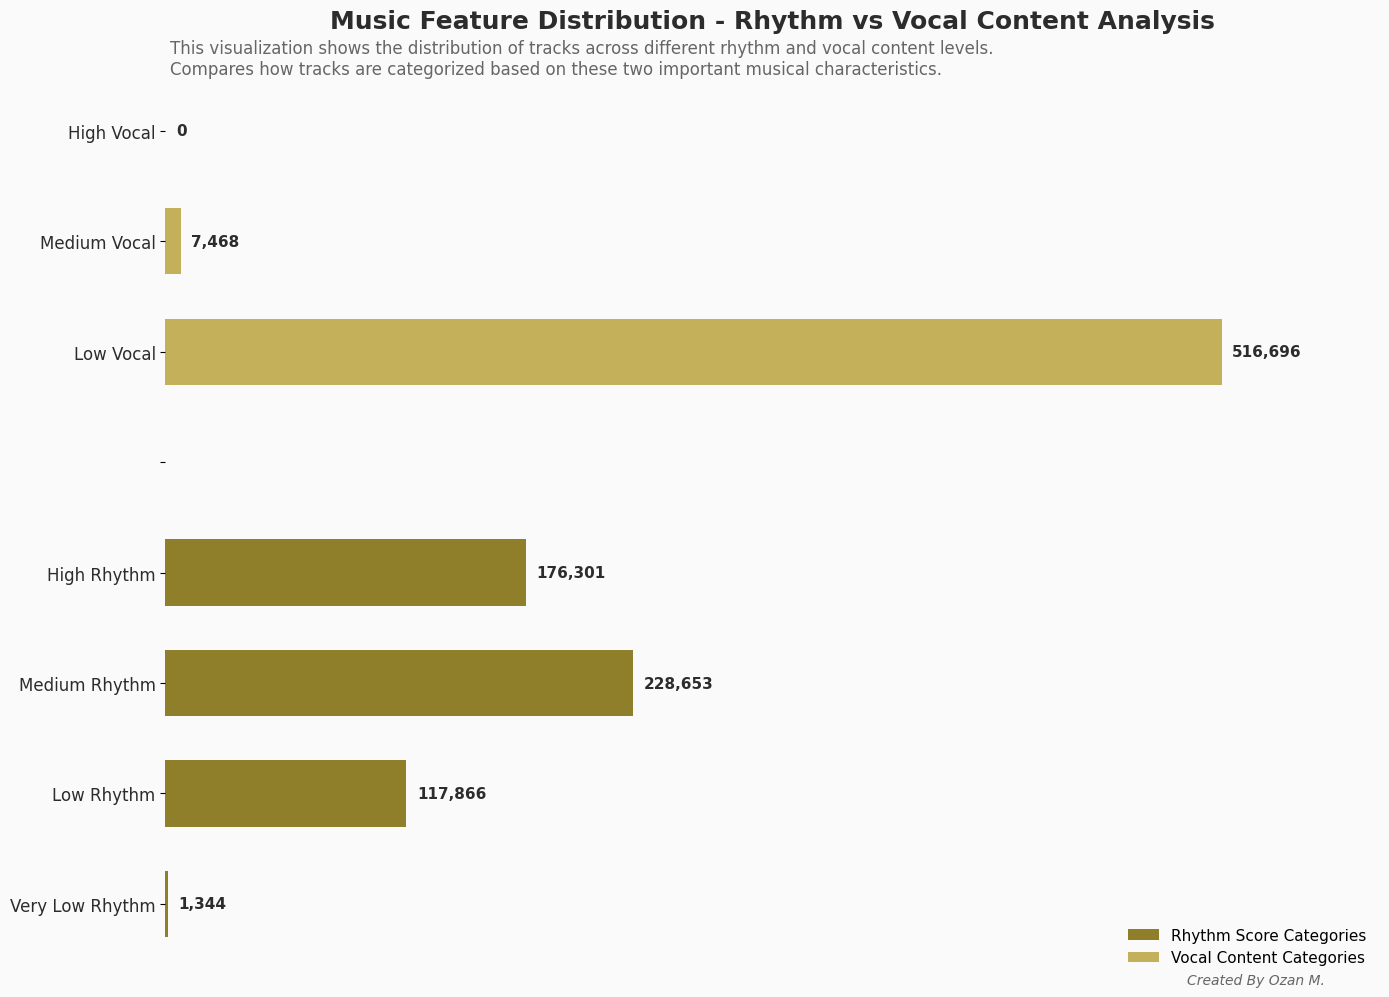

In [9]:
colors = ['#f8f4d9', '#c4b05a', '#8f7f2a', '#6b5500']

high_rhythm = df[df['RhythmScore'] >= 0.7]
medium_rhythm = df[(df['RhythmScore'] >= 0.5) & (df['RhythmScore'] < 0.7)]
low_rhythm = df[(df['RhythmScore'] >= 0.3) & (df['RhythmScore'] < 0.5)]
very_low_rhythm = df[df['RhythmScore'] < 0.3]

categories = ['Very Low Rhythm', 'Low Rhythm', 'Medium Rhythm', 'High Rhythm']
counts = [len(very_low_rhythm), len(low_rhythm), len(medium_rhythm), len(high_rhythm)]

high_vocal = df[df['VocalContent'] >= 0.5]
medium_vocal = df[(df['VocalContent'] >= 0.2) & (df['VocalContent'] < 0.5)]
low_vocal = df[df['VocalContent'] < 0.2]

vocal_categories = ['Low Vocal', 'Medium Vocal', 'High Vocal']
vocal_counts = [len(low_vocal), len(medium_vocal), len(high_vocal)]

fig, ax = plt.subplots(figsize=(14, 10))

rhythm_color = colors[2]
vocal_color = colors[1]

y_positions = list(range(len(categories)))
vocal_y_positions = [y + len(categories) + 1 for y in range(len(vocal_categories))]

rhythm_bars = ax.barh(y_positions, counts, color=rhythm_color, height=0.6, label='Rhythm Categories')
vocal_bars = ax.barh(vocal_y_positions, vocal_counts, color=vocal_color, height=0.6, label='Vocal Categories')

ax.set_title('Music Feature Distribution - Rhythm vs Vocal Content Analysis', 
             fontsize=18, fontweight='bold', pad=20, color='#2c2c2c')

fig.text(0.125, 0.92, 'This visualization shows the distribution of tracks across different rhythm and vocal content levels.\nCompares how tracks are categorized based on these two important musical characteristics.', 
         fontsize=12, color='#666666', ha='left')

all_labels = categories + [''] + vocal_categories
all_y_positions = y_positions + [len(categories)] + vocal_y_positions

ax.set_yticks(all_y_positions)
ax.set_yticklabels(all_labels, fontsize=12, color='#2c2c2c')

for bar, count in zip(rhythm_bars, counts):
    width = bar.get_width()
    ax.text(width + max(counts + vocal_counts) * 0.01, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', ha='left', va='center', 
            fontsize=11, fontweight='bold', color='#2c2c2c')

for bar, count in zip(vocal_bars, vocal_counts):
    width = bar.get_width()
    ax.text(width + max(counts + vocal_counts) * 0.01, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', ha='left', va='center', 
            fontsize=11, fontweight='bold', color='#2c2c2c')

ax.set_xlim(0, max(counts + vocal_counts) * 1.15)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])

legend_elements = [
    plt.Rectangle((0,0),1,3, facecolor=rhythm_color, label='Rhythm Score Categories'),
    plt.Rectangle((0,0),1,3, facecolor=vocal_color, label='Vocal Content Categories')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, frameon=False)

fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

fig.text(0.95, 0.01, 'Created By Ozan M.', 
         fontsize=10, color='#666666', ha='right', style='italic')

plt.tight_layout()
plt.show()

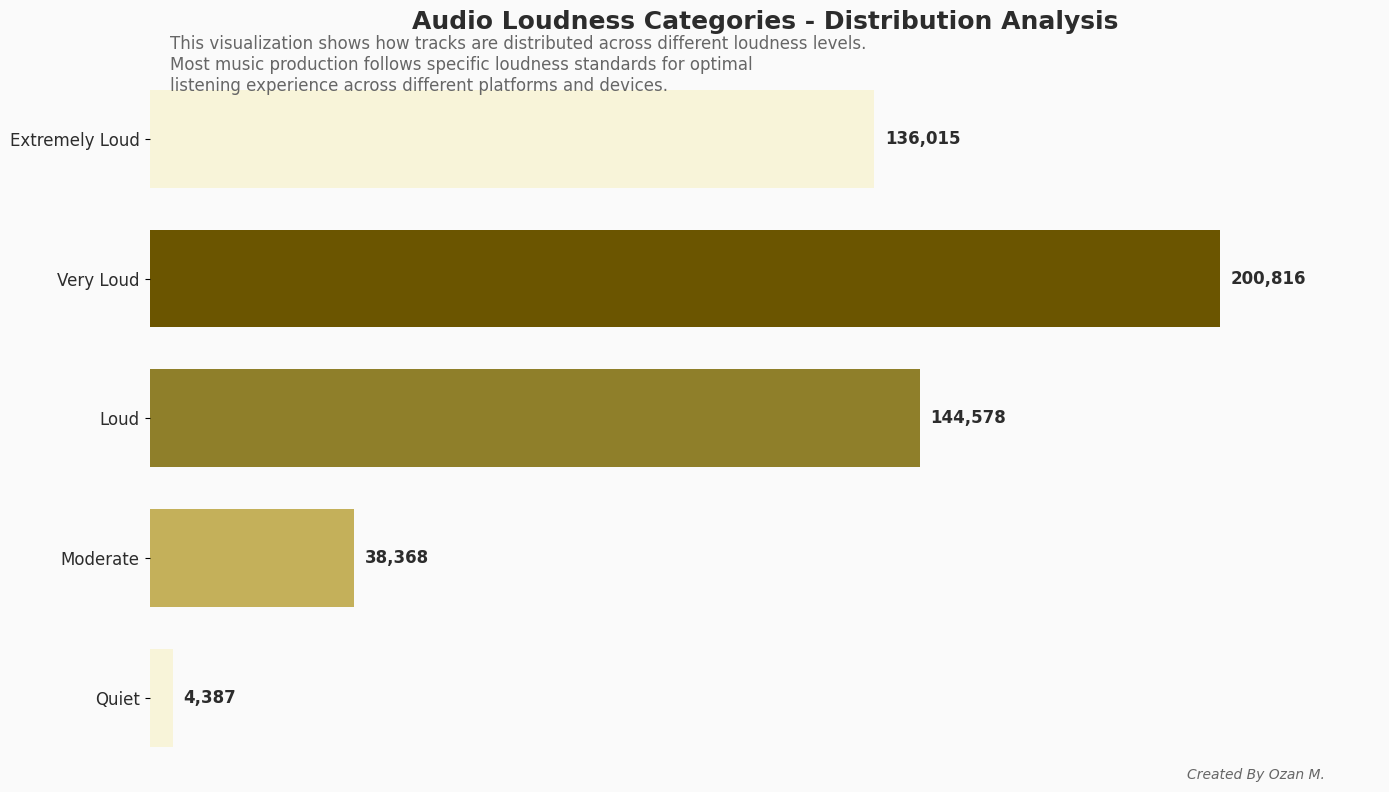

In [10]:
colors = ['#f8f4d9', '#c4b05a', '#8f7f2a', '#6b5500']

loudness_ranges = [
    (-60, -30, 'Very Quiet'),
    (-30, -20, 'Quiet'), 
    (-20, -15, 'Moderate'),
    (-15, -10, 'Loud'),
    (-10, -5, 'Very Loud'),
    (-5, 0, 'Extremely Loud')
]

category_counts = []
category_labels = []

for min_loud, max_loud, label in loudness_ranges:
    count = ((df['AudioLoudness'] >= min_loud) & (df['AudioLoudness'] < max_loud)).sum()
    if count > 0:
        category_counts.append(count)
        category_labels.append(label)

category_counts[-1] += (df['AudioLoudness'] >= 0).sum()

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(range(len(category_labels)), category_counts, 
               color=[colors[i % len(colors)] for i in range(len(category_labels))], 
               height=0.7)

ax.set_title('Audio Loudness Categories - Distribution Analysis', 
             fontsize=18, fontweight='bold', pad=20, color='#2c2c2c')

fig.text(0.125, 0.88, 'This visualization shows how tracks are distributed across different loudness levels.\nMost music production follows specific loudness standards for optimal\nlistening experience across different platforms and devices.', 
         fontsize=12, color='#666666', ha='left')

ax.set_yticks(range(len(category_labels)))
ax.set_yticklabels(category_labels, fontsize=12, color='#2c2c2c')

for bar, count in zip(bars, category_counts):
    width = bar.get_width()
    ax.text(width + max(category_counts) * 0.01, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', ha='left', va='center', 
            fontsize=12, fontweight='bold', color='#2c2c2c')

ax.set_xlim(0, max(category_counts) * 1.15)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])

fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

fig.text(0.95, 0.02, 'Created By Ozan M.', 
         fontsize=10, color='#666666', ha='right', style='italic')

plt.tight_layout()
plt.show()

<h2 style="
    background-color:#1a1a1a; 
    color:#FFD700; 
    padding:10px; 
    border-radius:6px; 
    font-family:sans-serif; 
    text-shadow: 0 0 5px #FFD700, 0 0 10px #FFD700, 0 0 20px #FFA500, 0 0 30px #FFA500, 0 0 40px #FFD700;
    ">
🧠 Modelling
</h2>

In [11]:
import lightgbm as lgb
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

train = pd.read_csv("/kaggle/input/playground-series-s5e9/train.csv", index_col="id")
test = pd.read_csv("/kaggle/input/playground-series-s5e9/test.csv", index_col="id")

print(f"Train: {train.shape}, Test: {test.shape}")

def create_features(df):
    df_new = df.copy()
    
    df_new['Duration_min'] = df['TrackDurationMs'] / 60000
    df_new['Loudness_norm'] = (df['AudioLoudness'] + 30) / 25
    
    df_new['Energy_Rhythm'] = df['Energy'] * df['RhythmScore']
    df_new['Mood_Energy'] = df['MoodScore'] * df['Energy']
    df_new['Vocal_Acoustic'] = df['VocalContent'] * df['AcousticQuality']
    
    df_new['Energy_sq'] = df['Energy'] ** 2
    df_new['Rhythm_sq'] = df['RhythmScore'] ** 2
    
    df_new['High_Energy'] = (df['Energy'] > 0.7).astype(int)
    df_new['High_Rhythm'] = (df['RhythmScore'] > 0.7).astype(int)
    df_new['Long_Track'] = (df_new['Duration_min'] > 4).astype(int)
    
    return df_new

print("Creating features...")
train_fe = create_features(train)
test_fe = create_features(test)

feature_cols = [col for col in train_fe.columns if col != 'BeatsPerMinute']
X = train_fe[feature_cols]
y = train_fe['BeatsPerMinute']
X_test = test_fe[feature_cols]

print(f"Total features: {len(feature_cols)}")

2025-09-11 08:55:41.324951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757580941.492001      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757580941.542404      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Train: (524164, 10), Test: (174722, 9)
Creating features...
Total features: 19


<h2 style="
    background-color:#1a1a1a; 
    color:#FFD700; 
    padding:10px; 
    border-radius:6px; 
    font-family:sans-serif; 
    text-shadow: 0 0 5px #FFD700, 0 0 10px #FFD700, 0 0 20px #FFA500, 0 0 30px #FFA500, 0 0 40px #FFD700;
    ">
⚡ LightGBM Model
</h2>

In [12]:
# LightGBM Model
def train_optuna_lightgbm(X, y, X_test):
    best_params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'seed': 42,
        'feature_pre_filter': False,
        'learning_rate': 0.001502328415098844,
        'num_leaves': 79,
        'max_depth': 14,
        'feature_fraction': 0.8933016300882094,
        'bagging_fraction': 0.9754103048412501,
        'bagging_freq': 7,
        'min_child_samples': 40,
        'lambda_l1': 7.10897934678165e-07,
        'lambda_l2': 7.81564014894075e-08,
        'n_jobs': -1
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"LGB Fold {fold + 1}")
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        train_data = lgb.Dataset(X_train, label=y_train)
        val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
        
        model = lgb.train(
            best_params,
            train_data,
            valid_sets=[val_data],
            num_boost_round=10000,
            callbacks=[
                lgb.early_stopping(200),
                lgb.log_evaluation(0)
            ]
        )
        
        val_pred = model.predict(X_val, num_iteration=model.best_iteration)
        test_pred = model.predict(X_test, num_iteration=model.best_iteration)
        
        oof_preds[val_idx] = val_pred
        test_preds += test_pred / 5
        
        fold_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
        fold_scores.append(fold_rmse)
        print(f"LGB Fold {fold + 1} RMSE: {fold_rmse:.5f}")
    
    cv_score = np.sqrt(mean_squared_error(y, oof_preds))
    print(f"LightGBM CV RMSE: {cv_score:.5f}")
    
    return oof_preds, test_preds, cv_score

<h2 style="
    background-color:#1a1a1a; 
    color:#FFD700; 
    padding:10px; 
    border-radius:6px; 
    font-family:sans-serif; 
    text-shadow: 0 0 5px #FFD700, 0 0 10px #FFD700, 0 0 20px #FFA500, 0 0 30px #FFA500, 0 0 40px #FFD700;
    ">
  XGB
</h2>

In [13]:
# def train_xgboost(X, y, X_test):
#    best_params = {
#        'objective': 'reg:squarederror',
#        'eval_metric': 'rmse',
#        'random_state': 42,
#        'learning_rate': 0.01,
#        'max_depth': 12,
#        'min_child_weight': 1,
#        'subsample': 0.9,
#        'colsample_bytree': 0.9,
#        'reg_alpha': 0.01,
#        'reg_lambda': 1,
#        'n_jobs': -1
#   }

#    kf = KFold(n_splits=5, shuffle=True, random_state=42)
#    oof_preds = np.zeros(len(X))
#    test_preds = np.zeros(len(X_test))
#    fold_scores = []
    
#    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
#        print(f"XGB Fold {fold + 1}")
#        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
#        model = xgb.XGBRegressor(**best_params, n_estimators=10000)
        
#        model.fit(
#            X_train, y_train,
#            eval_set=[(X_val, y_val)],
#            early_stopping_rounds=200,
#            verbose=False
#       )
        
#        val_pred = model.predict(X_val)
#        test_pred = model.predict(X_test)
        
#        oof_preds[val_idx] = val_pred
#        test_preds += test_pred / 5
        
#        fold_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
#        fold_scores.append(fold_rmse)
#        print(f"XGB Fold {fold + 1} RMSE: {fold_rmse:.5f}")
    
#    cv_score = np.sqrt(mean_squared_error(y, oof_preds))
#    print(f"XGBoost CV RMSE: {cv_score:.5f}")
    
 #   return oof_preds, test_preds, cv_score

<h2 style="
    background-color:#1a1a1a; 
    color:#FFD700; 
    padding:10px; 
    border-radius:6px; 
    font-family:sans-serif; 
    text-shadow: 0 0 5px #FFD700, 0 0 10px #FFD700, 0 0 20px #FFA500, 0 0 30px #FFA500, 0 0 40px #FFD700;
    ">
 ANN
</h2>

In [14]:
# def create_ann_model(input_dim):
#    model = Sequential([
#        Dense(512, activation='relu', input_shape=(input_dim,)),
#        BatchNormalization(),
#        Dropout(0.3),
 #       
  #      Dense(256, activation='relu'),
   #     BatchNormalization(),
    #    Dropout(0.3),
     #   
      #  Dense(128, activation='relu'),
        # BatchNormalization(),
       # Dropout(0.2),
        
       # Dense(64, activation='relu'),
       # BatchNormalization(),
       # Dropout(0.2),
        
       # Dense(32, activation='relu'),
       # Dropout(0.1),
        
       # Dense(1, activation='linear')
   # ])
    
    # model.compile(
      #  optimizer=Adam(learning_rate=0.001),
       # loss='mse',
        # metrics=['mae']
    # )
    
    # return model

# def train_ann(X, y, X_test):
    # Scale the features
 #   scaler = StandardScaler()
 #   X_scaled = scaler.fit_transform(X)
 #   X_test_scaled = scaler.transform(X_test)
    
  #  kf = KFold(n_splits=5, shuffle=True, random_state=42)
 #   oof_preds = np.zeros(len(X))
 #   test_preds = np.zeros(len(X_test))
#    fold_scores = []
    
  #  for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
   #     print(f"ANN Fold {fold + 1}")
    #    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
  #      y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
     #   model = create_ann_model(X_train.shape[1])
        
    #    callbacks = [
        #    EarlyStopping(patience=50, restore_best_weights=True, monitor='val_loss'),
        #    ReduceLROnPlateau(patience=20, factor=0.5, min_lr=1e-6, monitor='val_loss')
     #   ]
        
     #   model.fit(
     #       X_train, y_train,
      #      validation_data=(X_val, y_val),
      #      epochs=300,
       #     batch_size=512,
       #     callbacks=callbacks,
      #      verbose=0
       # )
        
       # val_pred = model.predict(X_val, verbose=0).flatten()
      #  test_pred = model.predict(X_test_scaled, verbose=0).flatten()
        
      #  oof_preds[val_idx] = val_pred
       # test_preds += test_pred / 5
        
      #  fold_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
      #  fold_scores.append(fold_rmse)
      #  print(f"ANN Fold {fold + 1} RMSE: {fold_rmse:.5f}")
    
   # cv_score = np.sqrt(mean_squared_error(y, oof_preds))
    # print(f"Neural Network CV RMSE: {cv_score:.5f}")
    
   # return oof_preds, test_preds, cv_score

In [15]:
print("=== TRAINING LIGHTGBM ===")
lgb_oof, lgb_test, lgb_score = train_optuna_lightgbm(X, y, X_test)

# print("\n=== TRAINING XGBOOST ===")
# xgb_oof, xgb_test, xgb_score = train_xgboost(X, y, X_test)

# print("\n=== TRAINING NEURAL NETWORK ===")
# ann_oof, ann_test, ann_score = train_ann(X, y, X_test)

=== TRAINING LIGHTGBM ===
LGB Fold 1
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[917]	valid_0's rmse: 26.4379
LGB Fold 1 RMSE: 26.43794
LGB Fold 2
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1049]	valid_0's rmse: 26.4828
LGB Fold 2 RMSE: 26.48277
LGB Fold 3
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[798]	valid_0's rmse: 26.5241
LGB Fold 3 RMSE: 26.52406
LGB Fold 4
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1764]	valid_0's rmse: 26.4438
LGB Fold 4 RMSE: 26.44380
LGB Fold 5
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1238]	valid_0's rmse: 26.4072
LGB Fold 5 RMSE: 26.40718
LightGBM CV RMSE: 26.45918


In [16]:
#total_score = lgb_score + xgb_score + ann_score
# lgb_weight = (1/lgb_score) / ((1/lgb_score) + (1/xgb_score) + (1/ann_score))
# xgb_weight = (1/xgb_score) / ((1/lgb_score) + (1/xgb_score) + (1/ann_score))
# ann_weight = (1/ann_score) / ((1/lgb_score) + (1/xgb_score) + (1/ann_score))

# print(f"\n=== ENSEMBLE WEIGHTS ===")
# print(f"LightGBM weight: {lgb_weight:.4f} (score: {lgb_score:.5f})")
# print(f"XGBoost weight: {xgb_weight:.4f} (score: {xgb_score:.5f})")
# print(f"Neural Network weight: {ann_weight:.4f} (score: {ann_score:.5f})")

# Create ensemble predictions
# ensemble_oof = lgb_weight * lgb_oof + xgb_weight * xgb_oof + ann_weight * ann_oof
# ensemble_test = lgb_weight * lgb_test + xgb_weight * xgb_test + ann_weight * ann_test

# ensemble_score = np.sqrt(mean_squared_error(y, ensemble_oof))
# print(f"\nEnsemble CV RMSE: {ensemble_score:.5f}")

# Create submission
# submission = pd.DataFrame({
#     'id': test.index,
#     'BeatsPerMinute': ensemble_test
# })

# submission.to_csv('ensemble_submission.csv', index=False)

# print(f"\n=== FINAL RESULTS ===")
# print(f"LightGBM: {lgb_score:.5f}")
# print(f"XGBoost: {xgb_score:.5f}")
# print(f"Neural Network: {ann_score:.5f}")
# print(f"Ensemble: {ensemble_score:.5f}")
# print("\nEnsemble model completed!")

<h2 style="
    background-color:#1a1a1a; 
    color:#FFD700; 
    padding:10px; 
    border-radius:6px; 
    font-family:sans-serif; 
    text-shadow: 0 0 5px #FFD700, 0 0 10px #FFD700, 0 0 20px #FFA500, 0 0 30px #FFA500, 0 0 40px #FFD700;
    ">
 ENSEMBLE
</h2>

<div style="background-color:white; color:black; padding:15px; border-radius:8px;">

<h3>Why this approach?</h3>

<p>
The results obtained in this study were generated using an <b>ensemble approach</b>, combining the outputs of 
<b>XGBoost</b>, <b>CatBoost</b>, and <b>artificial neural network (ANN)</b> models trained separately on a 
different notebook. Because the individual model training and optimization processes required high computational 
costs and lengthy runtime, the training of these models was completed externally, and the resulting predictions 
were then loaded and combined. As a result, the ensemble method yielded a more robust and generalizable score.
</p>

<p>
This approach aims to both utilize processing time efficiently and increase performance by leveraging the strengths 
of different algorithms.
</p>

</div>

In [17]:
sub = pd.read_csv("/kaggle/input/different-work/submission.csv")
sub.to_csv('submission.csv', index=False)